In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"..\Dataset\dataset_module_one_DM2.csv")

## CBLOF

In [3]:
from pyod.models.cblof import CBLOF
from sklearn.preprocessing import StandardScaler

In [4]:
X = df.values
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
clf = CBLOF(contamination=0.04)
clf.fit(X)

,n_clusters,8
,contamination,0.04
,clustering_estimator,None
,alpha,0.9
,beta,5
,use_weights,False
,check_estimator,False
,random_state,None
,n_jobs,None


In [6]:
outliers_cblof = clf.predict(X)
np.unique(outliers_cblof, return_counts=True)

(array([0, 1]), array([8121,  339]))

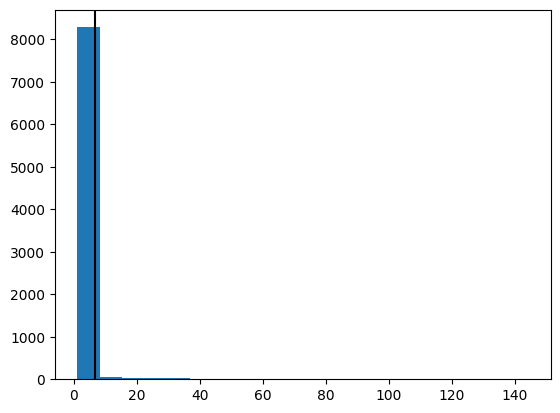

In [7]:
plt.hist(clf.decision_scores_, bins=20)
plt.axvline(np.min(clf.decision_scores_[np.where(outliers_cblof==1)]), c='k')
plt.show()

## Isolation Forest

In [8]:
from pyod.models.iforest import IsolationForest

In [9]:
clf = IsolationForest(contamination=0.04)
clf.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.04
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [10]:
outliers_if = clf.predict(X)
np.unique(outliers_if, return_counts=True)

(array([-1,  1]), array([ 339, 8121]))

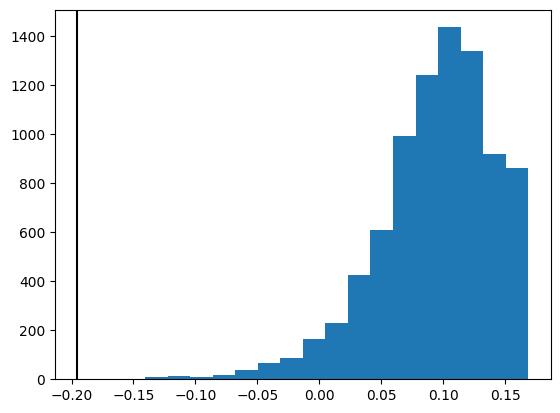

In [11]:
plt.hist(clf.decision_function(X), bins=20)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers_if==-1)]), c='k')
plt.show()

## ABOD

In [12]:
from pyod.models.abod import ABOD

In [13]:
clf = ABOD(contamination=0.04)
clf.fit(X)

,contamination,0.04
,n_neighbors,5
,method,'fast'
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,1


In [14]:
outliers_abod = clf.predict(X)
np.unique(outliers_abod, return_counts=True)

(array([0, 1]), array([8121,  339]))

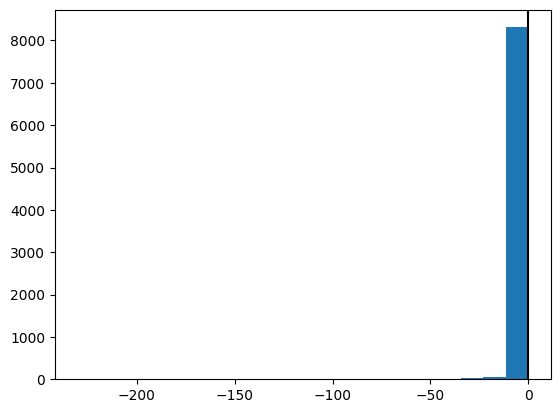

In [15]:
plt.hist(clf.decision_scores_, bins=20)
plt.axvline(np.min(clf.decision_scores_[np.where(outliers_abod==1)]), c='k')
plt.show()

### Verifica che siano stati identificati gli stessi outliers

In [16]:
common_outliers = (outliers_cblof == 1) & (outliers_if == -1) & (outliers_abod == 1)
df_outliers_comuni = df[common_outliers]
df_outliers_comuni

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_CU_Zone,FGC-FGC_GSND_Zone,FGC-FGC_GSD_Zone,FGC-FGC_PU_Zone,FGC-FGC_SRL_Zone,...,BIA-BIA_TBW,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Body_Mass_Index_Global,Body_Proportion,Fitness_Endurance-Time,Mean_Arterial_Pressure
306,16,0,65.0,93.0,5.000000,0.0,2.0,2.0,0.0,0.0,...,132.055000,1.380000,2.147374,91.000000,3.0,3.0,9.664477,3.035071,448.140476,100.333333
356,12,0,65.0,94.0,5.159865,1.0,2.0,2.0,1.0,0.0,...,71.207600,2.070129,4.040000,40.000000,0.0,0.0,3.110458,0.107249,503.783996,126.333333
580,10,1,41.0,68.0,4.000000,0.0,1.0,2.0,0.0,0.0,...,44.987000,1.985586,1.130000,84.000000,0.0,1.0,0.563884,1.283785,322.000000,152.666667
798,14,0,75.0,86.0,5.000000,0.0,1.0,1.0,0.0,1.0,...,102.027000,2.010429,2.230000,63.000000,0.0,1.0,5.208948,1.537960,447.888011,83.666667
921,16,0,50.0,81.0,5.000000,0.0,1.0,1.0,0.0,0.0,...,106.902000,1.260000,2.507981,93.000000,3.0,0.0,9.057035,4.935247,451.419081,83.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,12,0,65.5,73.5,3.000000,0.0,1.0,1.0,0.0,0.0,...,59.444046,3.000000,1.000000,52.408788,3.0,0.0,3.185434,1.560557,478.500000,83.666667
8300,16,1,71.0,71.0,4.500000,1.0,2.0,2.0,1.0,1.0,...,57.433088,2.000000,2.956022,46.000000,1.0,0.0,5.890030,-0.188560,510.944170,99.500000
8391,7,1,70.0,87.5,4.500000,1.0,3.0,2.0,0.0,1.0,...,44.987000,2.000000,3.000000,59.500000,1.0,0.0,4.293428,0.680394,520.285036,81.444462
8412,10,0,66.5,79.5,4.000000,1.0,1.0,2.0,1.0,1.0,...,35.045306,3.000000,3.000000,44.500000,0.0,0.0,0.165020,-0.960773,466.500000,70.833333


## Plot outliers

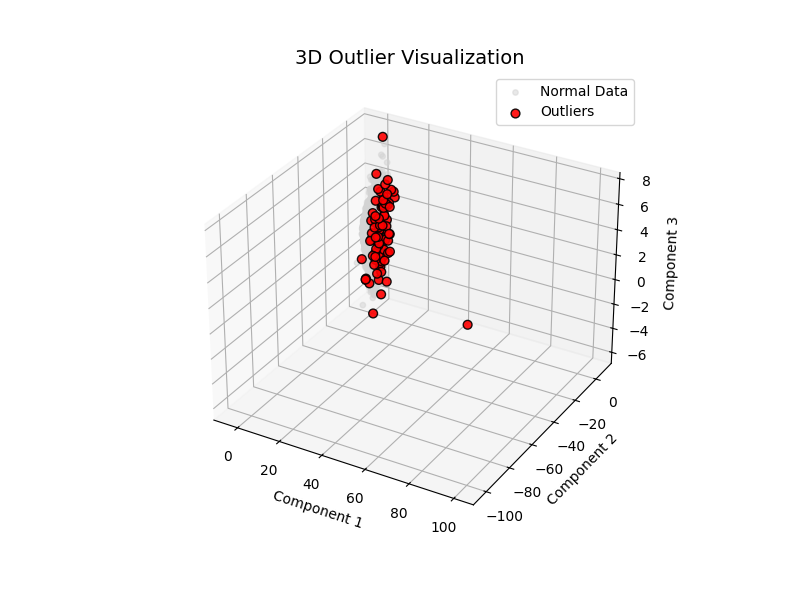

--- VARIANZA SPIEGATA DALLE COMPONENTI ---
Componente 1: 10.63%
Componente 2: 8.25%
Componente 3: 5.31%
------------------------------------------
Varianza complessiva spiegata in 3D: 24.18%


In [22]:
# %matplotlib widget
from sklearn.decomposition import PCA

# 1. Riduciamo il dataset a 3 dimensioni con la PCA
pca_3d = PCA(n_components=3, random_state=42)
X_pca3d = pca_3d.fit_transform(X)

# 2. Inizializziamo un grafico 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')

# 3. Plottiamo i dati normali (Inversione della maschera con ~)
ax.scatter(X_pca3d[~common_outliers, 0], 
           X_pca3d[~common_outliers, 1], 
           X_pca3d[~common_outliers, 2], 
           c='lightgrey', alpha=0.5, s=15, label='Normal Data')

# 4. Plottiamo i 77 outlier comuni
ax.scatter(X_pca3d[common_outliers, 0], 
           X_pca3d[common_outliers, 1], 
           X_pca3d[common_outliers, 2], 
           c='red', alpha=0.9, s=40, edgecolors='black', label='Outliers')

# 5. Etichette e legenda
ax.set_title('3D Outlier Visualization', fontsize=14)
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(loc='best')

plt.show()

# 1. Recuperiamo la varianza spiegata da ciascuna delle 3 componenti
varianza_per_componente = pca_3d.explained_variance_ratio_

# 2. Stampiamo i risultati per ogni componente
print("--- VARIANZA SPIEGATA DALLE COMPONENTI ---")
for i, varianza in enumerate(varianza_per_componente):
    print(f"Componente {i+1}: {varianza * 100:.2f}%")

# 3. Calcoliamo e stampiamo la varianza totale cumulata
varianza_totale_3d = sum(varianza_per_componente) * 100
print("------------------------------------------")
print(f"Varianza complessiva spiegata in 3D: {varianza_totale_3d:.2f}%")